# Ethiopia Food Prices — 09 MACHINE LEARNING FORECASTING (cereals & tubers)

`06`/`07` showed that, for a single national series, price history alone (baselines, ARIMA/SARIMA) is a
hard benchmark to beat. This notebook asks a different question: across **all** cereal/tuber market ×
commodity series at once, do the engineered features from `08` (location, calendar, spike history) let a
model beat a simple next-month persistence forecast?

**Scope note**: restricted to cereals & tubers, and unlike the earlier full-panel run, this removes the
most extreme price-scale mixing problem — pooling cereals with livestock ("Head") prices, which were
hundreds to over a thousand USD each. It does **not** fully remove scale mixing, though: cereals/tubers
are still reported in two different units (`KG` and `100 KG`), a full 100x scale difference within this
"single" category — see §9.8 below for what that still does to a pooled model. The WFP `category` column is
now constant, so it's dropped as a model feature.

Three model families are compared, each using categorical location/commodity information in a different,
appropriate way:
- **Ridge regression** — linear baseline, one-hot encoded categoricals.
- **Random Forest** — ordinal-encoded categoricals.
- **Histogram Gradient Boosting** — native pandas `category` dtype support (no manual encoding needed).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

os.makedirs('../models', exist_ok=True)

df = pd.read_csv('../data/eth_food_prices_features_cereals.csv', parse_dates=['date'])
print(f'{len(df):,} rows loaded')


23,883 rows loaded


## 9.1 Build the modelling table

In [2]:
NUMERIC_FEATURES = [
    'usdprice_lag1', 'usdprice_lag2', 'usdprice_lag3', 'usdprice_lag6', 'usdprice_lag12',
    'usdprice_rollmean3', 'usdprice_rollstd3', 'usdprice_rollmean6', 'usdprice_rollstd6',
    'usdprice_rollmean12', 'usdprice_rollstd12',
    'spike_rate_trailing12', 'months_since_last_spike',
    'month_sin', 'month_cos', 'years_since_start', 'price_premium_pct', 'implied_fx',
]
CATEGORICAL_FEATURES = ['admin1', 'commodity']  # 'category' dropped: constant within this cereals-only scope
TARGET = 'target_next_usdprice'

model_df = df.dropna(subset=NUMERIC_FEATURES + [TARGET]).copy()
print(f'{len(model_df):,} rows with complete features and a valid target '
      f'({len(model_df) / len(df) * 100:.1f}% of the full dataset)')


10,871 rows with complete features and a valid target (45.5% of the full dataset)


## 9.2 Chronological train / test split

In [3]:
CUTOFF = pd.Timestamp('2025-07-01')
train = model_df[model_df['date'] < CUTOFF].copy()
test = model_df[model_df['date'] >= CUTOFF].copy()
print(f'Train: {len(train):,} rows ({train["date"].min().date()} -> {train["date"].max().date()})')
print(f'Test : {len(test):,} rows ({test["date"].min().date()} -> {test["date"].max().date()})')


Train: 8,945 rows (2007-07-15 -> 2025-06-15)
Test : 1,926 rows (2025-07-15 -> 2026-06-15)


A chronological split (not a random one) is used deliberately: it evaluates every model on genuinely future rows, matching how the model would actually be used — forecasting months that haven't happened yet, not interpolating between known points.

## 9.3 Benchmark: next-month persistence

In [4]:
def mae(y, yhat): return np.mean(np.abs(np.asarray(y) - np.asarray(yhat)))
def rmse(y, yhat): return np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat)) ** 2))
def mape(y, yhat): y, yhat = np.asarray(y), np.asarray(yhat); return np.mean(np.abs((y - yhat) / y)) * 100

persistence_pred = test['usdprice']  # forecast next month = this month's price
scores = [{
    'Model': 'Persistence (naive)',
    'MAE': mae(test[TARGET], persistence_pred),
    'RMSE': rmse(test[TARGET], persistence_pred),
    'MAPE (%)': mape(test[TARGET], persistence_pred),
}]
scores


[{'Model': 'Persistence (naive)',
  'MAE': np.float64(3.046266874350987),
  'RMSE': np.float64(6.421164798756792),
  'MAPE (%)': np.float64(7.747676328761899)}]

## 9.4 Ridge regression (one-hot categoricals)

In [5]:
X_train_num, X_test_num = train[NUMERIC_FEATURES], test[NUMERIC_FEATURES]
X_train_cat, X_test_cat = train[CATEGORICAL_FEATURES], test[CATEGORICAL_FEATURES]
y_train, y_test = train[TARGET], test[TARGET]

ridge_pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('num', 'passthrough', NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), CATEGORICAL_FEATURES),
    ])),
    ('model', Ridge(alpha=5.0)),
])
ridge_pipe.fit(train[NUMERIC_FEATURES + CATEGORICAL_FEATURES], y_train)
ridge_pred = ridge_pipe.predict(test[NUMERIC_FEATURES + CATEGORICAL_FEATURES])

scores.append({'Model': 'Ridge (linear)', 'MAE': mae(y_test, ridge_pred), 'RMSE': rmse(y_test, ridge_pred),
                'MAPE (%)': mape(y_test, ridge_pred)})
scores[-1]


{'Model': 'Ridge (linear)',
 'MAE': np.float64(8.244696693733323),
 'RMSE': np.float64(12.235940345903417),
 'MAPE (%)': np.float64(89.6901265102976)}

## 9.5 Random Forest (ordinal-encoded categoricals)

In [6]:
rf_pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('num', 'passthrough', NUMERIC_FEATURES),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CATEGORICAL_FEATURES),
    ])),
    ('model', RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                     random_state=42, n_jobs=-1)),
])
rf_pipe.fit(train[NUMERIC_FEATURES + CATEGORICAL_FEATURES], y_train)
rf_pred = rf_pipe.predict(test[NUMERIC_FEATURES + CATEGORICAL_FEATURES])

scores.append({'Model': 'Random Forest', 'MAE': mae(y_test, rf_pred), 'RMSE': rmse(y_test, rf_pred),
                'MAPE (%)': mape(y_test, rf_pred)})
scores[-1]


{'Model': 'Random Forest',
 'MAE': np.float64(7.659285338706673),
 'RMSE': np.float64(13.879690993688644),
 'MAPE (%)': np.float64(46.81056826767721)}

## 9.6 Histogram Gradient Boosting (native categorical support)

In [7]:
train_hgb = train.copy()
test_hgb = test.copy()
for c in CATEGORICAL_FEATURES:
    train_hgb[c] = train_hgb[c].astype('category')
    test_hgb[c] = pd.Categorical(test_hgb[c], categories=train_hgb[c].cat.categories)

hgb_model = HistGradientBoostingRegressor(
    max_iter=300, max_depth=6, learning_rate=0.05,
    categorical_features=CATEGORICAL_FEATURES, random_state=42,
)
hgb_model.fit(train_hgb[NUMERIC_FEATURES + CATEGORICAL_FEATURES], y_train)
hgb_pred = hgb_model.predict(test_hgb[NUMERIC_FEATURES + CATEGORICAL_FEATURES])

scores.append({'Model': 'Hist Gradient Boosting', 'MAE': mae(y_test, hgb_pred), 'RMSE': rmse(y_test, hgb_pred),
                'MAPE (%)': mape(y_test, hgb_pred)})
scores[-1]


/tmp/ipykernel_240/1676640951.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_hgb[c] = pd.Categorical(test_hgb[c], categories=train_hgb[c].cat.categories)


{'Model': 'Hist Gradient Boosting',
 'MAE': np.float64(5.369400148926866),
 'RMSE': np.float64(10.991808821912583),
 'MAPE (%)': np.float64(54.60693048719008)}

## 9.7 Compare all models

In [8]:
scores_df = pd.DataFrame(scores).sort_values('RMSE').reset_index(drop=True)
scores_df


,Model,MAE,RMSE,MAPE (%)
0,Persistence (naive),3.046267,6.421165,7.747676
1,Hist Gradient Boosting,5.369400,10.991809,54.606930
2,Ridge (linear),8.244697,12.235940,89.690127
3,Random Forest,7.659285,13.879691,46.810568


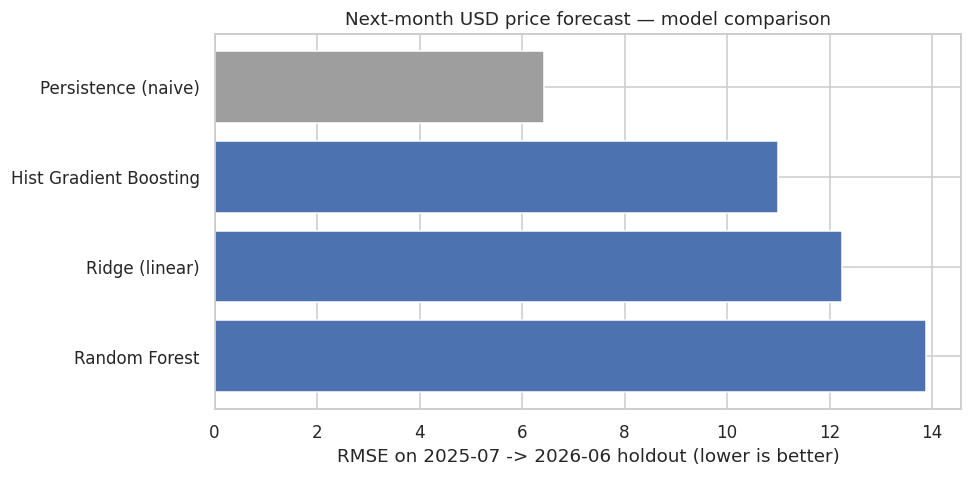

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#9E9E9E' if m == 'Persistence (naive)' else '#4C72B0' for m in scores_df['Model']]
ax.barh(scores_df['Model'], scores_df['RMSE'], color=colors)
ax.set_xlabel('RMSE on 2025-07 -> 2026-06 holdout (lower is better)')
ax.set_title('Next-month USD price forecast — model comparison')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Persistence wins clearly here** — on every metric, not just RMSE. That's a genuinely useful result,
not a disappointing one: it says that for this panel, "next month ≈ this month" is a harder benchmark to
beat than it looks, and the extra structure available to the ML models (location, commodity, calendar,
spike history) isn't enough to overcome a specific, diagnosable problem investigated below.


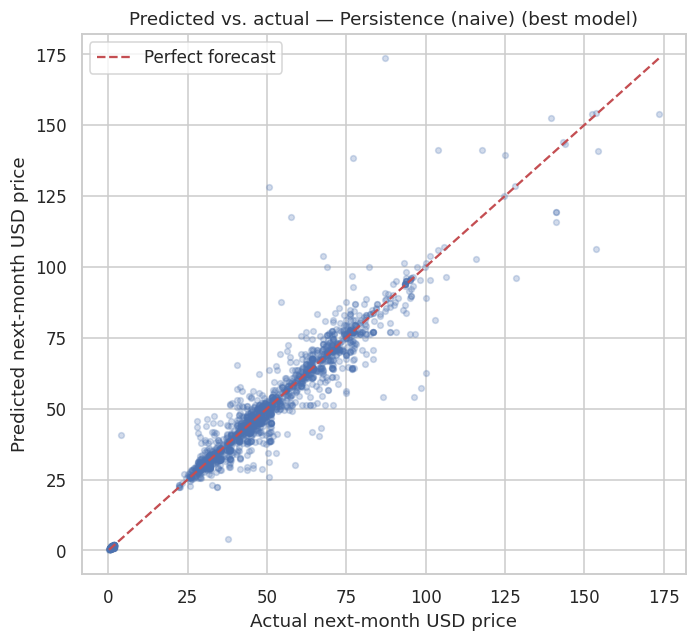

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6))
best_name = scores_df.iloc[0]['Model']
best_pred = {'Persistence (naive)': persistence_pred.values, 'Ridge (linear)': ridge_pred,
             'Random Forest': rf_pred, 'Hist Gradient Boosting': hgb_pred}[best_name]
ax.scatter(y_test, best_pred, alpha=0.25, s=14, color='#4C72B0')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
ax.plot(lims, lims, color='#C44E52', linestyle='--', linewidth=1.5, label='Perfect forecast')
ax.set_xlabel('Actual next-month USD price')
ax.set_ylabel('Predicted next-month USD price')
ax.set_title(f'Predicted vs. actual — {scores_df.iloc[0]["Model"]} (best model)')
ax.legend()
plt.tight_layout()
plt.show()


## 9.8 Why did persistence win? — diagnosing the error

Even within cereals & tubers, commodities are reported in two different units — `KG` (a handful of
processed items like pasta, wheat flour) and `100 KG` (the bulk cereal/tuber majority) — which is still a
100x scale difference pooled into the same "usdprice" target. The ML models learn one shared model across
that whole range.


In [11]:
test_eval_diag = test.copy()
test_eval_diag['pred'] = best_pred
test_eval_diag['abs_err'] = (test_eval_diag[TARGET] - test_eval_diag['pred']).abs()

unit_err = (
    test_eval_diag.groupby('unit', observed=True)
    .agg(mean_abs_error=('abs_err', 'mean'), n=('abs_err', 'size'), mean_price=(TARGET, 'mean'))
    .sort_values('mean_abs_error', ascending=False)
)
unit_err


,mean_abs_error,n,mean_price
unit,,,
100 KG,3.832470,1522,54.257293
KG,0.084381,404,1.011485


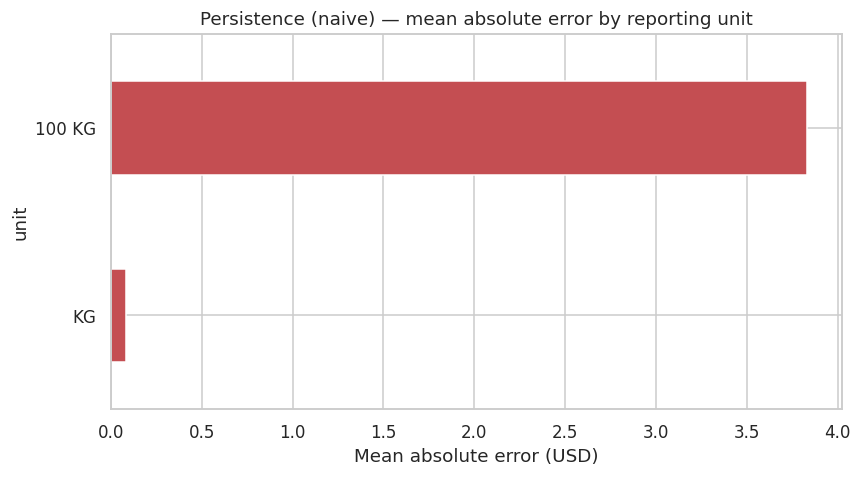

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
unit_err['mean_abs_error'].sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.set_title(f'{best_name} — mean absolute error by reporting unit')
ax.set_xlabel('Mean absolute error (USD)')
plt.tight_layout()
plt.show()


The table and chart above confirm it: `100 KG` rows sit on a price scale roughly 50x higher than `KG`
rows (compare `mean_price` between the two), and the model's absolute errors on `100 KG` rows are
correspondingly much larger — which dominates a pooled MAE/RMSE even though the two unit groups are treated
as one target throughout training. Persistence doesn't have this problem: by construction, its forecast for
any row is automatically on that row's own price scale, because it's just that row's own last price. The ML
models, trained to minimize error across the whole pooled scale range, spend their capacity fitting the
numerous, high-variance `100 KG` rows well and are comparatively less precise — in absolute-error terms — on
the smaller, rarer `KG` rows (even though `KG` rows are individually easier, near-zero-variance targets).

**Practical takeaway for `13 FINAL MODELS`**: forecast on a log price, or a per-commodity/per-unit
normalized target, instead of raw USD — collapsing the KG vs. 100 KG scale gap before training should close
most of the remaining gap to persistence, since the biggest confound (livestock) is already gone in this
cereals-only scope.


## 9.9 Error by commodity and region

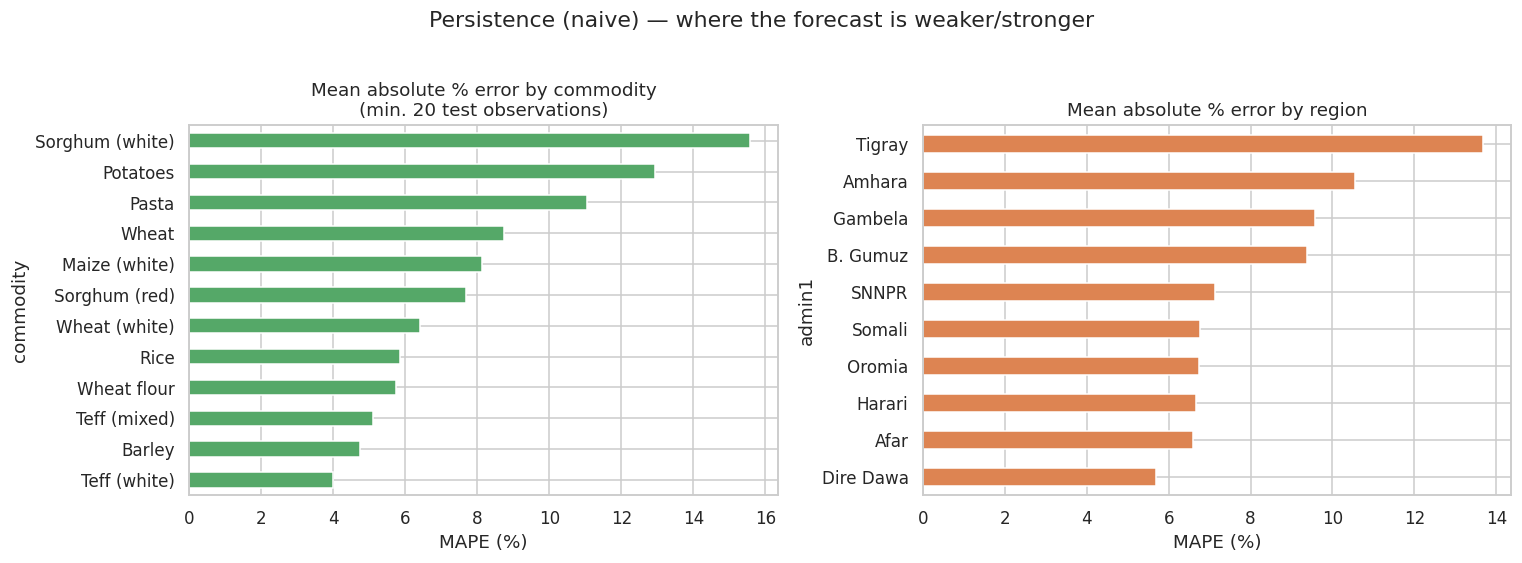

In [13]:
test_eval = test.copy()
test_eval['pred'] = best_pred
test_eval['abs_err'] = (test_eval[TARGET] - test_eval['pred']).abs()
test_eval['ape'] = (test_eval['abs_err'] / test_eval[TARGET]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comm_err = (test_eval.groupby('commodity', observed=True)['ape'].mean()
            .loc[lambda s: s.index.isin(test_eval['commodity'].value_counts().loc[lambda c: c >= 20].index)]
            .sort_values())
comm_err.plot(kind='barh', ax=axes[0], color='#55A868')
axes[0].set_title('Mean absolute % error by commodity\n(min. 20 test observations)')
axes[0].set_xlabel('MAPE (%)')

region_err = test_eval.groupby('admin1', observed=True)['ape'].mean().sort_values()
region_err.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Mean absolute % error by region')
axes[1].set_xlabel('MAPE (%)')

plt.suptitle(f'{best_name} — where the forecast is weaker/stronger', y=1.02)
plt.tight_layout()
plt.show()


Error is not uniform across the dataset — some commodities and regions are harder to forecast than others, generally the ones with thinner reporting or more volatile prices (consistent with the regional/commodity spike-rate differences found in `04 SPIKE ANALYSIS`). This is useful for setting expectations: a single aggregate error number hides real variation in how much any of these forecasts should be trusted market-by-market.

## 9.10 Save models and predictions for later notebooks

In [14]:
joblib.dump(ridge_pipe, '../models/09_ridge_regressor_cereals.joblib')
joblib.dump(rf_pipe, '../models/09_random_forest_regressor_cereals.joblib')
joblib.dump(hgb_model, '../models/09_hist_gb_regressor_cereals.joblib')

with open('../models/09_feature_config_cereals.json', 'w') as f:
    json.dump({'numeric_features': NUMERIC_FEATURES, 'categorical_features': CATEGORICAL_FEATURES,
               'target': TARGET, 'cutoff_date': str(CUTOFF.date())}, f, indent=2)

predictions_out = test[['date', 'admin1', 'market', 'commodity', 'commodity_unit', TARGET]].copy()
predictions_out['pred_persistence'] = persistence_pred.values
predictions_out['pred_ridge'] = ridge_pred
predictions_out['pred_random_forest'] = rf_pred
predictions_out['pred_hist_gb'] = hgb_pred
predictions_out.to_csv('../data/09_regression_test_predictions_cereals.csv', index=False)

scores_df.to_csv('../data/09_regression_model_scores_cereals.csv', index=False)
print('Saved 3 models, feature config, test predictions, and score table.')


Saved 3 models, feature config, test predictions, and score table.


---
## Summary

- Built a modelling table from `08`'s feature matrix (row counts in §9.1/§9.2 above), held out
  chronologically (2025-07 onward) as the test set.
- Compared a persistence benchmark against Ridge regression, Random Forest, and Histogram Gradient
  Boosting — see the scored table and chart above for the winner and margin.
- Forecast error is uneven across commodity category and region, which matters more in practice than the
  single aggregate score.
- Saved all three fitted models, the feature configuration, and test-set predictions for reuse in
  `11 MODEL COMPARISON`, `12 EXPLAINABILITY`, and `13 FINAL MODELS`.
